In [137]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.large_repr", "truncate")

In [138]:
#Data Inspection
economic_data = pd.read_csv("../raw_data/economic_data.csv")
economic_data.head()

,category,indicator,sub_indicator,locality,gender,council_district,fiscal_year,fy_qtr,calendar_year,cy_qtr,quarter_start,as_of_date,unit_of_measure,unit_text,value,source,CD #,Proportions
0,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2004-03,2004.0,2004-01,01/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"1,311,096.5",City Of Los Angeles Department Of Building And Safety,1.0,NaN
1,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2004-04,2004.0,2004-02,04/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"3,081,184.9",City Of Los Angeles Department Of Building And Safety,1.0,NaN
2,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2005-01,2005.0,2004-03,07/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"4,150,152.8",City Of Los Angeles Department Of Building And Safety,1.0,NaN
3,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2005-02,2005.0,2004-04,10/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"1,288,147.1",City Of Los Angeles Department Of Building And Safety,1.0,NaN
4,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2005,2005-03,2005.0,2005-01,01/01/2005,05/08/2015,$,Seasonally Adjusted And Smoothed,"1,971,990.6",City Of Los Angeles Department Of Building And Safety,1.0,NaN


In [139]:
economic_data.shape

(30752, 18)

In [140]:
economic_data.columns

Index(['category', 'indicator', 'sub_indicator', 'locality', 'gender',
       'council_district', 'fiscal_year', 'fy_qtr', 'calendar_year', 'cy_qtr',
       'quarter_start', 'as_of_date', 'unit_of_measure', 'unit_text', 'value',
       'source', 'CD #', 'Proportions'],
      dtype='object')

In [141]:
economic_data['council_district'].unique()

array(['1', nan, '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', 'City Total', '99'], dtype=object)

In [142]:
# Define valid districts as integers
valid_districts = list(range(1, 16))

# Make sure council_district is numeric
economic_data['council_district'] = pd.to_numeric(economic_data['council_district'], errors='coerce')

# Keep only rows where council_district is 1-15
economic_data = economic_data[economic_data['council_district'].isin(valid_districts)]
economic_data['council_district'].unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15.])

In [143]:
economic_data.shape

(23220, 18)

In [144]:
# Keep only rows where calendar_year is 2010
economic_data = economic_data[
    economic_data['cy_qtr'].isin(["2010-01", "2010-02", "2010-03", "2010-04"])
]
economic_data.shape

(2640, 18)

In [145]:
economic_data['category'].unique()

array(['Building Permits', 'Employment', 'Wages'], dtype=object)

In [146]:
economic_data['indicator'].unique()

array(['Multi-family Permit Values', 'Multi-family Permits',
       'New Commercial Permit Values',
       'Non-residential Alteration Permit Values',
       'Non-residential Permit Values', 'Single-family Permit Values',
       'Single-family Permits', 'Employment By Establishment Size',
       'Employment By Establishment Wage', 'Employment By Industry',
       'Establishment Change By Industry', 'Total Employment',
       'Average Annual Wage'], dtype=object)

In [147]:
economic_data['sub_indicator'].unique()

array([nan, '50 To 250 Employees', 'Greater Than 250 Employees',
       'Less Than 50 Employees', '$25,000 To $50,000',
       '$50,000 To $100,000', 'Greater Than $100,000',
       'Less Than $25,000', 'Administrative Support',
       'Durable Goods Manufacturing', 'Education', 'Financial Activities',
       'Health Care', 'Information', 'Leisure And Hospitality',
       'Non-durable Goods', 'Nr/construction', 'Other Services',
       'Prof, Sci, Tech, And Management', 'Retail Trade',
       'Transportation, Warehousing, And Utilities', 'Wholesale Trade',
       'Total All Industries'], dtype=object)

In [148]:
economic_data['locality'].unique()

array(['Los Angeles City'], dtype=object)

In [149]:
economic_data['gender'].unique()

array(['All'], dtype=object)

In [150]:
economic_data['unit_of_measure'].unique()

array(['$', '#'], dtype=object)

In [151]:
economic_data['unit_text'].unique()

array(['Seasonally Adjusted And Smoothed', 'Smoothed',
       'Seasonally Adjusted', nan], dtype=object)

In [152]:
economic_data['value'].unique()

array(['5,787,811.5', '0', '15,185,973.3', ..., '48,184.3', '48,707.8',
       '50,425.7'], dtype=object)

In [153]:
economic_data['source'].unique()

array(['City Of Los Angeles Department Of Building And Safety',
       'Employment Development Department, Beacon Economics',
       'Employment Development Department'], dtype=object)

In [154]:
economic_data['CD #'].unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15.])

In [155]:
economic_data['Proportions'].unique()

array([nan], dtype=object)

In [156]:
# Columns to drop - they are not important
cols_to_drop = ['locality', 'gender', 'fiscal_year', 'fy_qtr', 'calendar_year', 'quarter_start',
                'as_of_date', 'unit_text', 'source', 'CD #', 'Proportions']

# Drop columns
economic_data = economic_data.drop(columns=[col for col in cols_to_drop if col in economic_data.columns])

# Check the result
economic_data.columns

Index(['category', 'indicator', 'sub_indicator', 'council_district', 'cy_qtr',
       'unit_of_measure', 'value'],
      dtype='object')

In [157]:
# Group indicators by category
pd.set_option('display.max_colwidth', None)  # prevent truncation
indicators_by_category = economic_data.groupby('category')['indicator'].unique()
indicators_by_category

category
Building Permits    [Multi-family Permit Values, Multi-family Permits, New Commercial Permit Values, Non-residential Alteration Permit Values, Non-residential Permit Values, Single-family Permit Values, Single-family Permits]
Employment                                                                       [Employment By Establishment Size, Employment By Establishment Wage, Employment By Industry, Establishment Change By Industry, Total Employment]
Wages                                                                                                                                                                                                       [Average Annual Wage]
Name: indicator, dtype: object

In [158]:
economic_data.shape

(2640, 7)

In [159]:
economic_data

,category,indicator,sub_indicator,council_district,cy_qtr,unit_of_measure,value
25,Building Permits,Multi-family Permit Values,NaN,1.0,2010-01,$,"5,787,811.5"
26,Building Permits,Multi-family Permit Values,NaN,1.0,2010-02,$,0
27,Building Permits,Multi-family Permit Values,NaN,1.0,2010-03,$,0
28,Building Permits,Multi-family Permit Values,NaN,1.0,2010-04,$,"15,185,973.3"
69,Building Permits,Multi-family Permit Values,NaN,2.0,2010-01,$,"476,251"
70,Building Permits,Multi-family Permit Values,NaN,2.0,2010-02,$,"3,004,680.7"
71,Building Permits,Multi-family Permit Values,NaN,2.0,2010-03,$,"19,019,450.9"
72,Building Permits,Multi-family Permit Values,NaN,2.0,2010-04,$,"15,474,458.5"
112,Building Permits,Multi-family Permit Values,NaN,3.0,2010-01,$,"7,073,517.2"
113,Building Permits,Multi-family Permit Values,NaN,3.0,2010-02,$,"4,257,949.3"


In [160]:
wages_2010 = economic_data[
    (economic_data['indicator'] == 'Average Annual Wage') &
    (economic_data['cy_qtr'].str.startswith('2010'))
].copy()

wages_2010['value'] = (
    wages_2010['value']
        .str.replace(',', '', regex=False)
        .astype(float)
)

wages_2010

,category,indicator,sub_indicator,council_district,cy_qtr,unit_of_measure,value
30309,Wages,Average Annual Wage,NaN,2.0,2010-01,$,40631.3
30310,Wages,Average Annual Wage,NaN,2.0,2010-02,$,41361.2
30311,Wages,Average Annual Wage,NaN,2.0,2010-03,$,41701.4
30312,Wages,Average Annual Wage,NaN,2.0,2010-04,$,45071.0
30324,Wages,Average Annual Wage,NaN,1.0,2010-01,$,42836.5
30325,Wages,Average Annual Wage,NaN,1.0,2010-02,$,43283.4
30326,Wages,Average Annual Wage,NaN,1.0,2010-03,$,43067.9
30327,Wages,Average Annual Wage,NaN,1.0,2010-04,$,43227.5
30365,Wages,Average Annual Wage,NaN,3.0,2010-01,$,51340.5
30366,Wages,Average Annual Wage,NaN,3.0,2010-02,$,54016.2


In [164]:
# Sort strictly by wage value (highest first)
avg_wage_by_district = (
    wages_2010
        .groupby('council_district')['value']
        .mean()
        .reset_index()
        .sort_values('value', ascending=False)
        .reset_index(drop=True)
)

print(avg_wage_by_district)

    council_district      value
0                5.0  78815.650
1               14.0  69560.925
2                4.0  62295.000
3               11.0  61785.750
4               13.0  54527.125
5                3.0  52878.850
6               15.0  48426.875
7                7.0  45148.325
8                6.0  43998.925
9               12.0  43272.975
10               1.0  43103.825
11              10.0  42641.950
12               9.0  42437.450
13               2.0  42191.225
14               8.0  29165.575


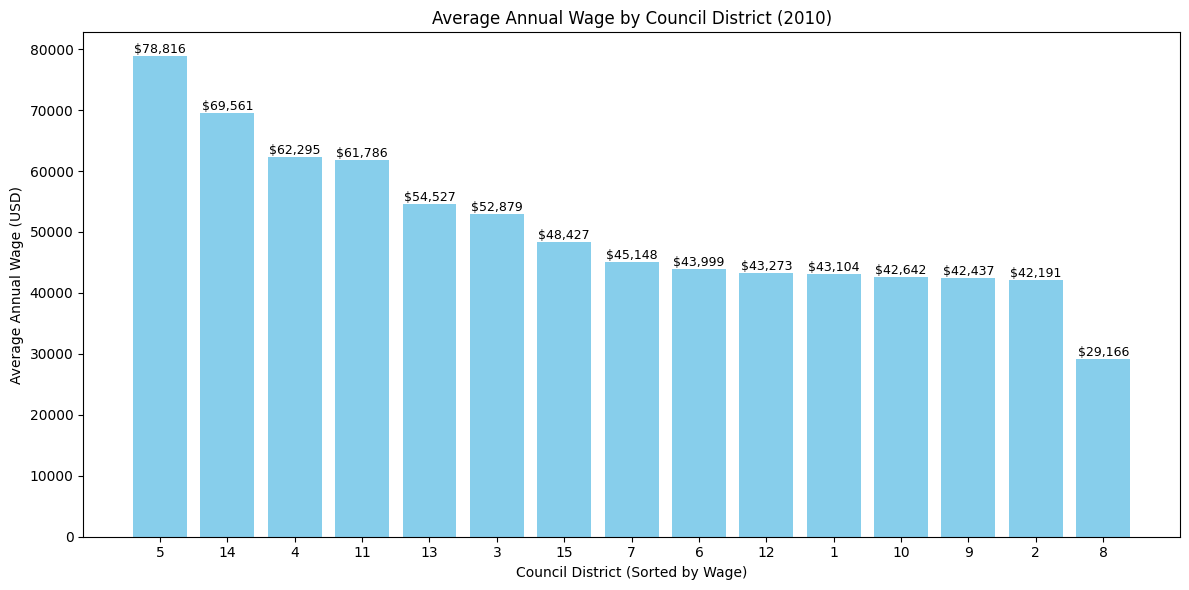

In [167]:
import pandas as pd

# Convert district to string for labeling
avg_wage_by_district['council_district'] = (
    avg_wage_by_district['council_district']
        .astype(int)
        .astype(str)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    avg_wage_by_district['council_district'],
    avg_wage_by_district['value'],
    color='skyblue'
)

# Add exact value on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x-position
        height,                             # y-position
        f"${height:,.0f}",                  # formatted text
        ha='center', va='bottom', fontsize=9
    )

plt.xlabel('Council District (Sorted by Wage)')
plt.ylabel('Average Annual Wage (USD)')
plt.title('Average Annual Wage by Council District (2010)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [169]:
# --- Filter only Total Employment for 2010 ---
employment_2010 = economic_data[
    (economic_data['indicator'] == 'Total Employment') &
    (economic_data['cy_qtr'].str.startswith('2010'))
].copy()

# --- Clean value column (remove commas and convert to float) ---
employment_2010['value'] = (
    employment_2010['value']
        .str.replace(',', '', regex=False)
        .astype(float)
)

employment_2010

,category,indicator,sub_indicator,council_district,cy_qtr,unit_of_measure,value
27620,Employment,Total Employment,Total All Industries,1.0,2010-01,#,90108.6
27621,Employment,Total Employment,Total All Industries,1.0,2010-02,#,95891.3
27622,Employment,Total Employment,Total All Industries,1.0,2010-03,#,96871.7
27623,Employment,Total Employment,Total All Industries,1.0,2010-04,#,92914.2
27644,Employment,Total Employment,Total All Industries,2.0,2010-01,#,59362.8
27645,Employment,Total Employment,Total All Industries,2.0,2010-02,#,58713.5
27646,Employment,Total Employment,Total All Industries,2.0,2010-03,#,59966.0
27647,Employment,Total Employment,Total All Industries,2.0,2010-04,#,59583.2
27668,Employment,Total Employment,Total All Industries,3.0,2010-01,#,96906.4
27669,Employment,Total Employment,Total All Industries,3.0,2010-02,#,96892.8


In [170]:
# --- Compute annual average per district ---
avg_employment_by_district = (
    employment_2010
        .groupby('council_district')['value']
        .mean()
        .reset_index()
        .sort_values('value', ascending=False)  # Sort by value
        .reset_index(drop=True)
)

print(avg_employment_by_district)

    council_district       value
0               14.0  316649.000
1                5.0  189243.725
2               11.0  140895.800
3                4.0   98931.325
4               12.0   98286.600
5                3.0   97065.050
6                1.0   93946.450
7               13.0   89061.350
8                6.0   71522.225
9                9.0   70937.050
10              10.0   63890.600
11              15.0   60015.925
12               2.0   59406.375
13               7.0   50637.025
14               8.0   20589.600


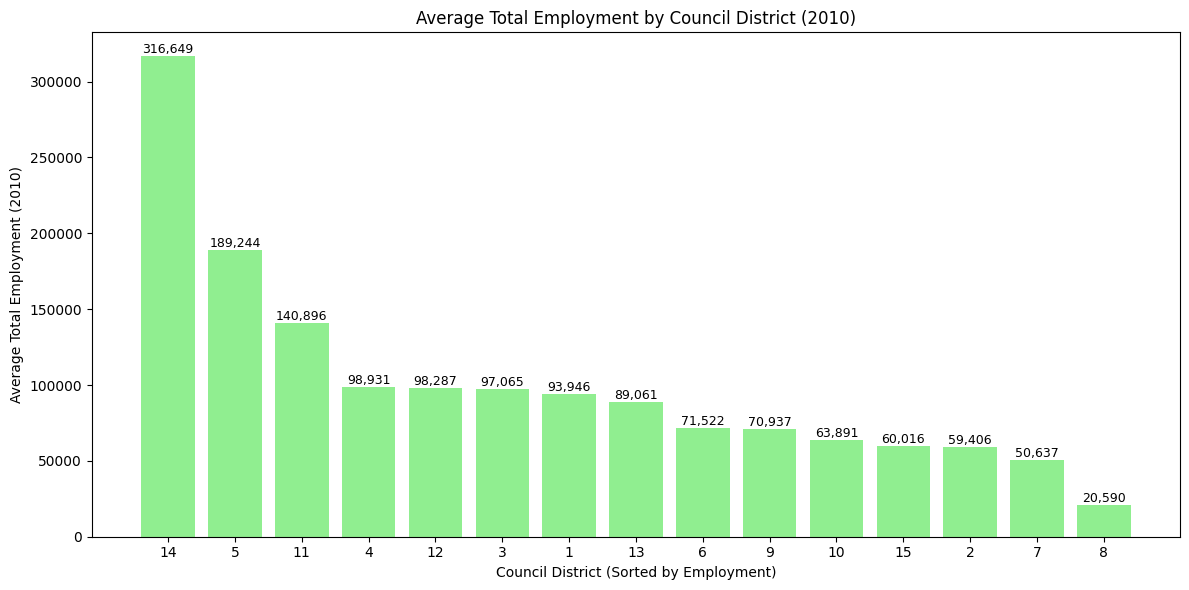

In [171]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert district to string for labeling
avg_employment_by_district['council_district'] = (
    avg_employment_by_district['council_district']
        .astype(int)
        .astype(str)
)

# --- Plot ---
plt.figure(figsize=(12,6))

bars = plt.bar(
    avg_employment_by_district['council_district'],
    avg_employment_by_district['value'],
    color='lightgreen'
)

# Add exact value on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",  # formatted with commas
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel('Council District (Sorted by Employment)')
plt.ylabel('Average Total Employment (2010)')
plt.title('Average Total Employment by Council District (2010)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()